<a href="https://colab.research.google.com/github/harshchamp/A-B-testing-Model/blob/main/AB_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter




### Loading Data

This code block loads the `cookie_cats.csv` dataset using `kagglehub` and displays the first 5 rows to give a preview of the data.

In [2]:
file_path = "cookie_cats.csv"

# Load the latest version

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yufengsui/mobile-games-ab-testing",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_5438/2674362095.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'mobile-games-ab-testing' dataset.
First 5 records:    userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True


### Displaying DataFrame

This cell simply displays the entire DataFrame to show its content.

In [3]:
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


### Checking for Missing Values

This code checks for any missing values in each column of the DataFrame and sums them up. The output shows that there are no missing values.

In [4]:
df.isna().sum()

,0
userid,0
version,0
sum_gamerounds,0
retention_1,0
retention_7,0


### Checking for Duplicate User IDs

This code verifies if there are any duplicate `userid` entries in the dataset. The output indicates there are no duplicate user IDs, which is good for analysis.

In [5]:
print(df['userid'].duplicated().sum())

0


### DataFrame Information

This provides a concise summary of the DataFrame, including the data types of each column, the number of non-null values, and memory usage. It's useful for a quick overview of the data structure.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


### DataFrame Shape

This cell outputs the dimensions of the DataFrame, showing the number of rows and columns.

In [7]:
df.shape

(90189, 5)

### Descriptive Statistics for 'sum_gamerounds'

This code provides descriptive statistics for the 'sum_gamerounds' column, including count, mean, standard deviation, min, max, and quartiles. This helps in understanding the distribution of game rounds played.

In [8]:
df['sum_gamerounds'].describe()

,sum_gamerounds
count,90189.000000
mean,51.872457
std,195.050858
min,0.000000
25%,5.000000
50%,16.000000
75%,51.000000
max,49854.000000


### Histogram of 'sum_gamerounds'

This histogram visualizes the distribution of 'sum_gamerounds'. The `xlim` is set to 0-2000 to better observe the distribution, as the max value is very high.

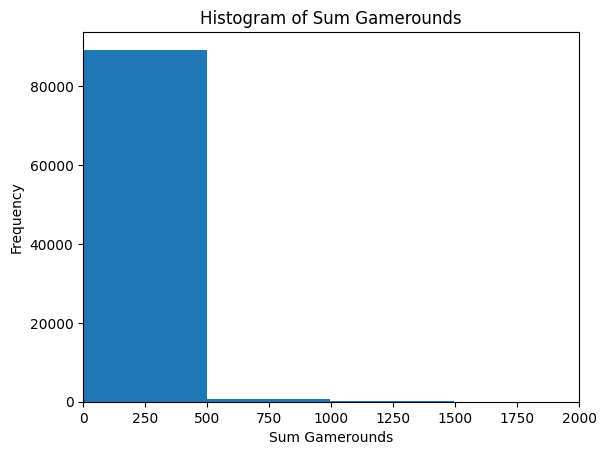

In [9]:
plt.hist(df['sum_gamerounds'], bins=100)
plt.xlabel('Sum Gamerounds')
plt.xlim(0, 2000)
plt.ylabel('Frequency')
plt.title('Histogram of Sum Gamerounds')
plt.show()

### Boxplot of 'sum_gamerounds'

This boxplot provides another visualization of the distribution of 'sum_gamerounds' and helps in identifying potential outliers. The presence of a very long whisker indicates many outliers with high game rounds.

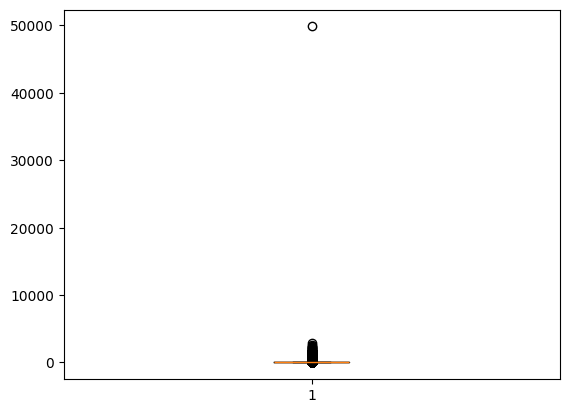

In [10]:
plt.boxplot(df['sum_gamerounds'])
plt.show()

In [23]:
df[(df['version'] == 'gate_30') & (df['retention_1']== True)]['sum_gamerounds'].describe()

,sum_gamerounds
count,20034.000000
mean,94.411700
std,135.037697
min,0.000000
25%,22.000000
50%,48.000000
75%,111.000000
max,2961.000000


In [24]:
df[(df['version'] == 'gate_40') & (df['retention_1']== True)]['sum_gamerounds'].describe()

,sum_gamerounds
count,20119.000000
mean,95.381182
std,137.887256
min,0.000000
25%,21.000000
50%,49.000000
75%,112.000000
max,2640.000000


In [25]:
df[(df['version'] == 'gate_30') & (df['retention_7']== True)]['sum_gamerounds'].describe()

,sum_gamerounds
count,8502.000000
mean,165.962479
std,568.000576
min,0.000000
25%,48.000000
50%,105.000000
75%,208.000000
max,49854.000000


In [26]:
df[(df['version'] == 'gate_40') & (df['retention_7']== True)]['sum_gamerounds'].describe()

,sum_gamerounds
count,8279.000000
mean,165.649837
std,183.792499
min,0.000000
25%,52.000000
50%,111.000000
75%,211.000000
max,2294.000000


### Outlier Detection and Removal

This block calculates the Interquartile Range (IQR) to identify and filter out outliers from the 'sum_gamerounds' column. Outliers are defined as values falling outside 1.5 times the IQR from the first (Q1) and third (Q3) quartiles.

In [11]:
q1= df['sum_gamerounds'].quantile(0.25)
q3= df['sum_gamerounds'].quantile(0.75)
iqr= q3-q1
lower_bound= q1-1.5*iqr
upper_bound= q3+1.5*iqr
outliers= df[(df['sum_gamerounds']<lower_bound) | (df['sum_gamerounds']>upper_bound)]

### Boxplot of 'sum_gamerounds' After Outlier Removal

This boxplot displays the distribution of 'sum_gamerounds' after removing the identified outliers. This provides a clearer view of the data without the influence of extreme values.

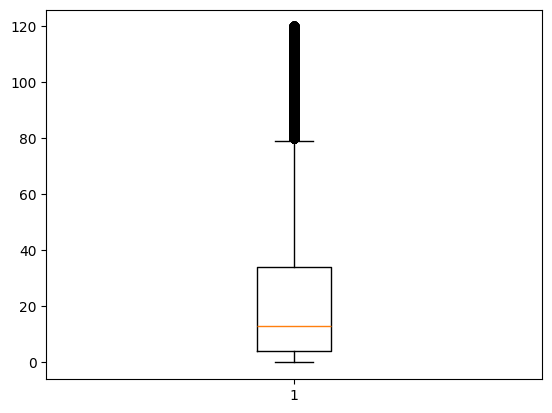

In [12]:
df_filtered = df[(df['sum_gamerounds']>=lower_bound) & (df['sum_gamerounds']<=upper_bound)]
plt.boxplot(df_filtered['sum_gamerounds'])
plt.show()

### Descriptive Statistics for Filtered 'sum_gamerounds'

This provides descriptive statistics for the 'sum_gamerounds' column after removing outliers, offering a more representative view of the central tendency and spread of the majority of players' game rounds.

In [13]:
df_filtered['sum_gamerounds'].describe()

,sum_gamerounds
count,80012.000000
mean,23.979178
std,27.481366
min,0.000000
25%,4.000000
50%,13.000000
75%,34.000000
max,120.000000


### Histogram of Filtered 'sum_gamerounds'

This histogram visualizes the distribution of 'sum_gamerounds' after outlier removal. This confirms that most users played a small number of rounds, as indicated by the earlier text cell.

below histogram confirms thats most user played small rounds.

### Filtering Data by Version and Retention

This code filters the `df_filtered` DataFrame to show only users who belong to the 'gate_30' version and had 'retention_1' as True (meaning they returned after 1 day). This helps in analyzing specific user segments.

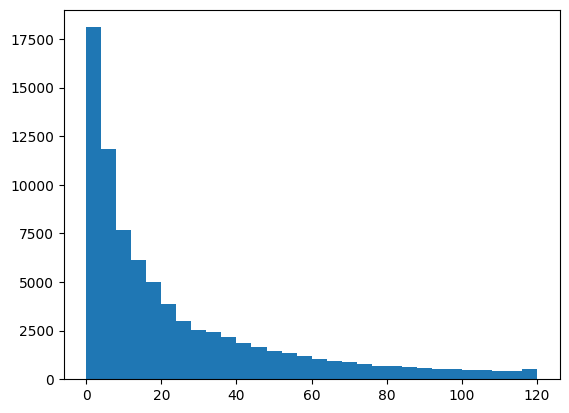

In [14]:
plt.hist(df_filtered['sum_gamerounds'], bins=30)
plt.show()

Total we have got 2  gates and 2 retention type so total posibilities are 2^2 = 4 we can plot these 4 types toget view or

In [18]:
df_filtered[(df_filtered['version'] == 'gate_30') & (df_filtered['retention_1']== True)]['sum_gamerounds'].describe()

,sum_gamerounds
count,15423.000000
mean,41.690786
std,29.983310
min,0.000000
25%,17.000000
50%,35.000000
75%,60.000000
max,120.000000


In [19]:
df_filtered[(df_filtered['version'] == 'gate_40') & (df_filtered['retention_1']== True)]['sum_gamerounds'].describe()

,sum_gamerounds
count,15478.000000
mean,42.280656
std,30.908286
min,0.000000
25%,17.000000
50%,34.000000
75%,62.000000
max,120.000000


In [20]:
df_filtered[(df_filtered['version'] == 'gate_30') & (df_filtered['retention_7']== True)]['sum_gamerounds'].describe()

,sum_gamerounds
count,4682.000000
mean,55.780863
std,32.212640
min,0.000000
25%,29.000000
50%,53.000000
75%,81.000000
max,120.000000


In [21]:
df_filtered[(df_filtered['version'] == 'gate_40') & (df_filtered['retention_7']== True)]['sum_gamerounds'].describe()

,sum_gamerounds
count,4433.000000
mean,57.440334
std,33.618387
min,0.000000
25%,29.000000
50%,55.000000
75%,85.000000
max,120.000000
